# Prac 05

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

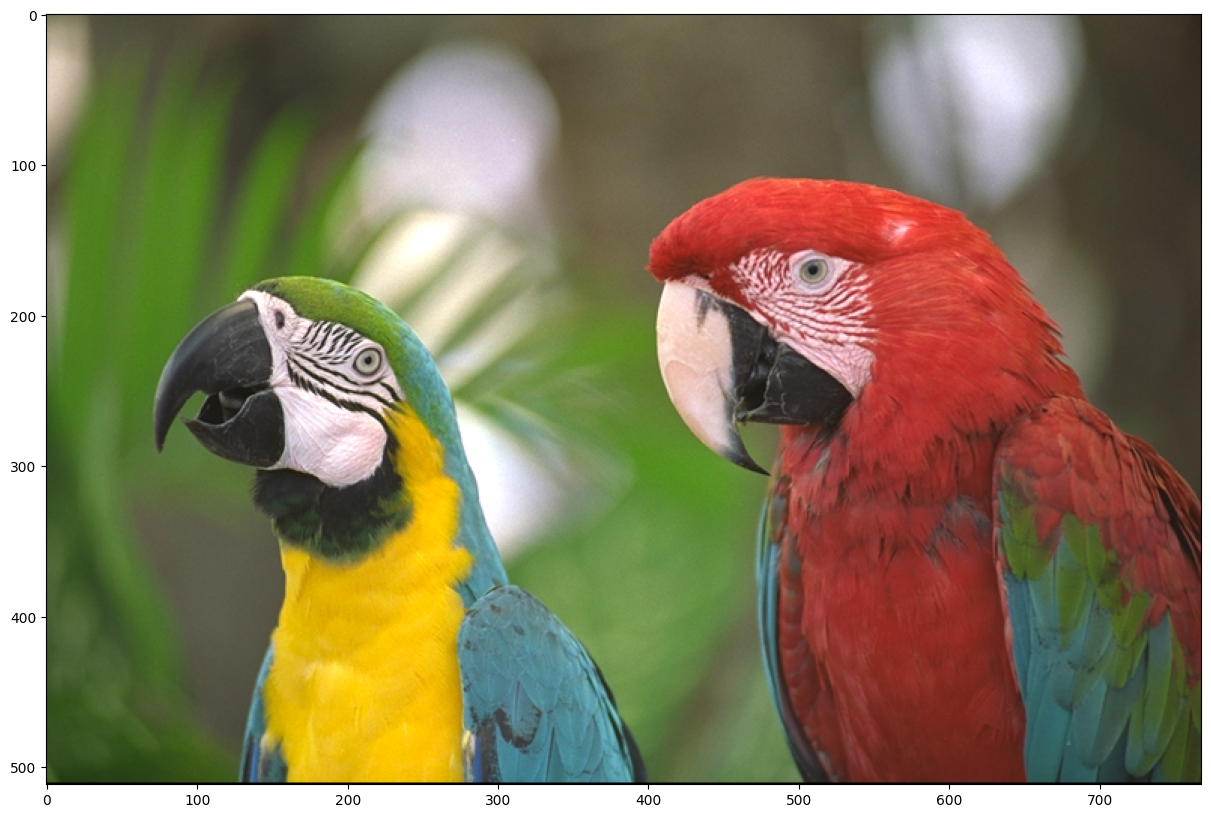

In [2]:
# Load image
img = cv2.imread('/content/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [3]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [4]:
# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c, :]

        # Find the closest colour from the pallette (Euclidean distance)
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]

        # Apply quantization
        quantized[r, c, :] = new_pixel

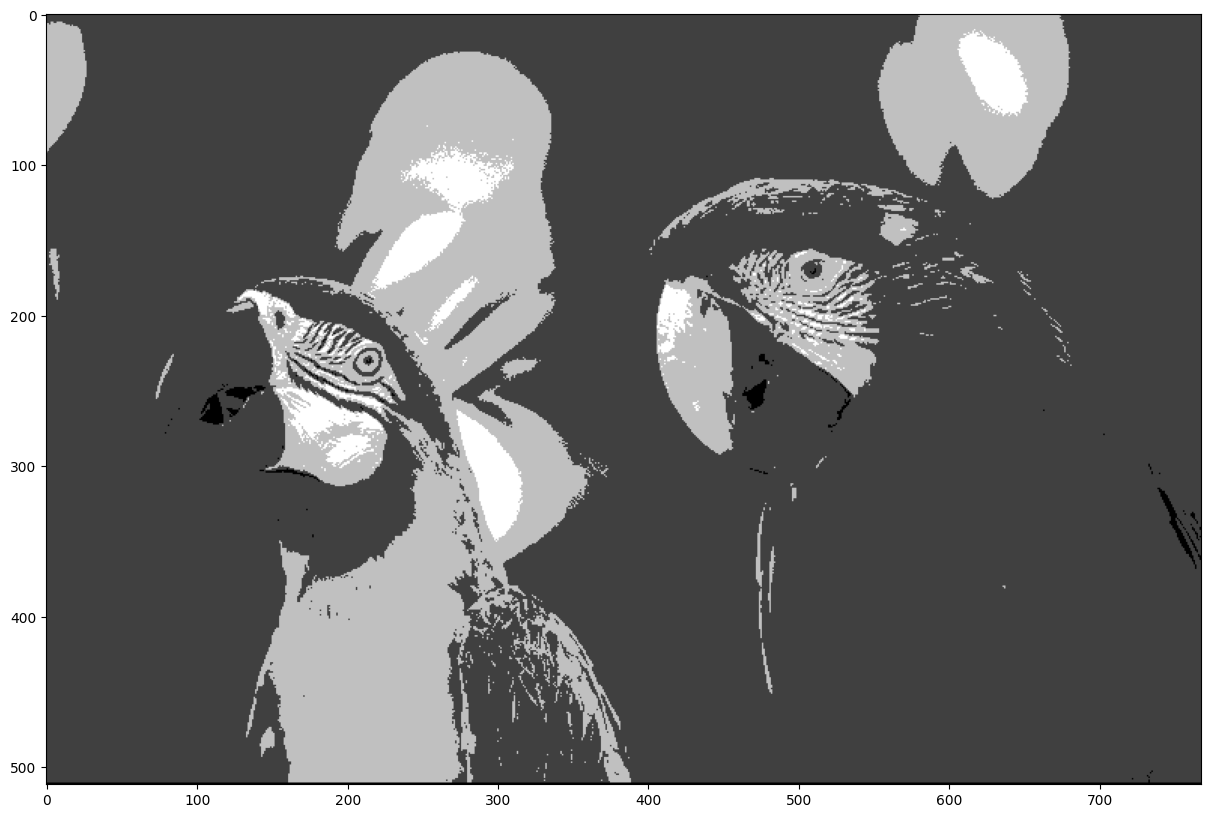

In [5]:
plt.imshow(quantized.astype(np.uint8))

In [10]:
# Compute average quantization error
avg_quant_error = np.mean(np.linalg.norm(img - quantized, axis=2))
print('Average quantization error:', avg_quant_error)

Average quantization error: 67.73236


#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [12]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_tmp[r, c, :]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]

        # Compute quantization error
        quant_error = pixel - new_pixel

        # Diffuse the quantization error accroding to the FS diffusion matrix
        img_tmp[r, c + 1, :] += quant_error * 7 / 16
        img_tmp[r + 1, c - 1, :] += quant_error * 3 / 16
        img_tmp[r + 1, c, :] += quant_error * 5 / 16
        img_tmp[r + 1, c + 1, :] += quant_error * 1 / 16


        dithering[r, c, :] = new_pixel

dithering = np.clip(dithering, 0, 255)

(<Axes: title={'center': 'Dithering'}>,
 Text(0.5, 1.0, 'Dithering'))

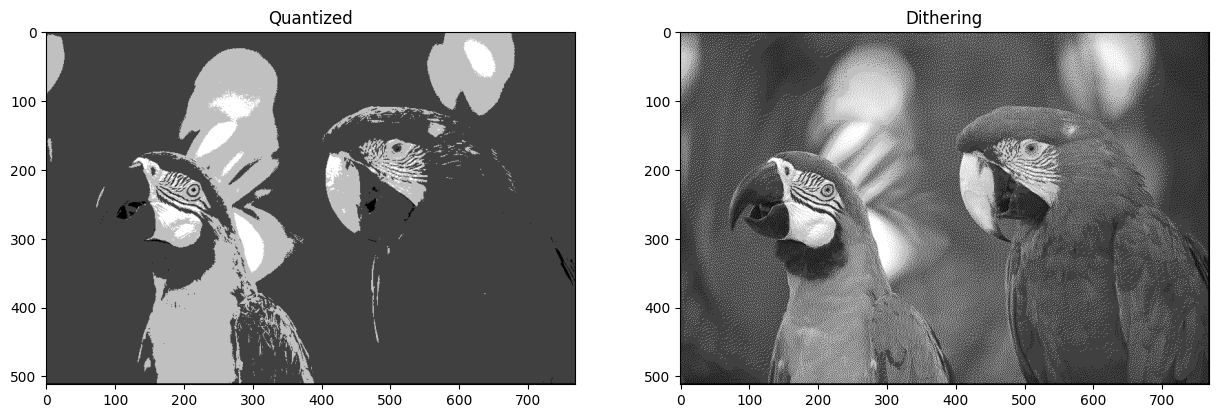

In [13]:
plt.subplot(121), plt.imshow(quantized.astype(np.uint8)), plt.title('Quantized')
plt.subplot(122), plt.imshow(dithering.astype(np.uint8)), plt.title('Dithering')

In [14]:
# Compute average quantization error for dithered image
avg_dith_error = np.mean(np.linalg.norm(img - dithering, axis=2))
print('Average dithering error:', avg_dith_error)

Average dithering error: 82.23369


### Questions
* Which image has higher quantization error? Optimally quantized or dithered?

Dithering has a larger average error because it intentionally distributes the error across neighboring pixels, making local deviations larger.

* Which image looks better to you?

Dithering looks better, probably because smoother transitions between colors look better than sharp blocks.

* Can you repeat the same process using only two colours: black and white? Show me :-)

Yes

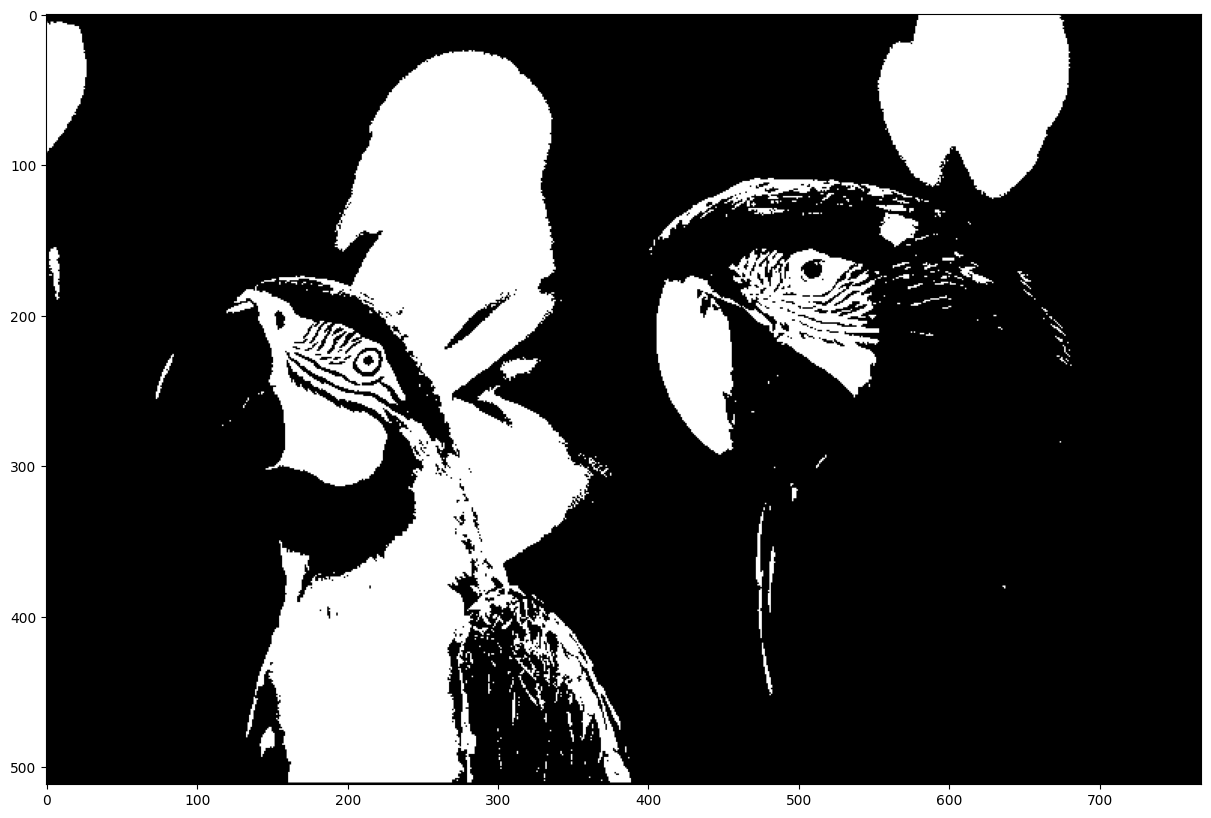

In [18]:
colors = np.array([[0, 0, 0], [255, 255, 255]])

# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c, :]

        # Find the closest colour from the pallette (Euclidean distance)
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]

        # Apply quantization
        quantized[r, c, :] = new_pixel

plt.imshow(quantized.astype(np.uint8))

(<Axes: title={'center': 'Dithering'}>,
 Text(0.5, 1.0, 'Dithering'))

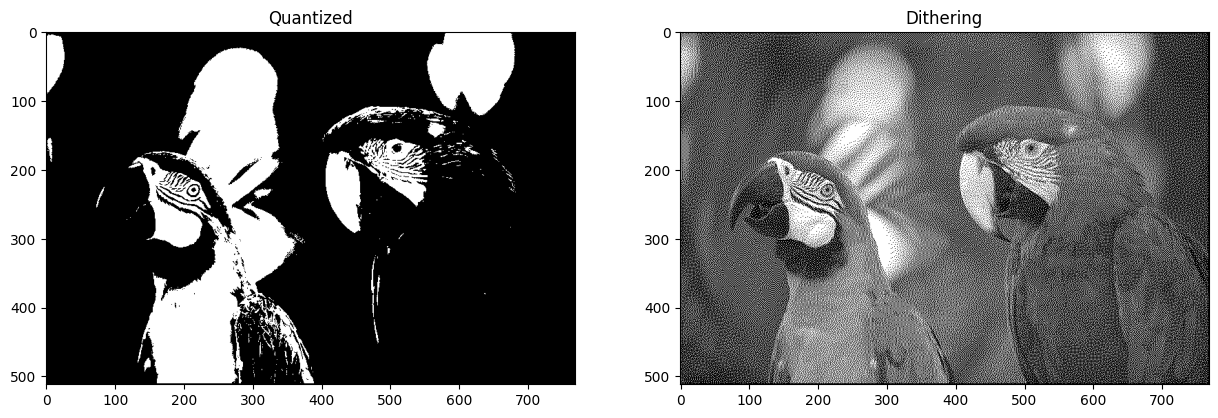

In [20]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_tmp[r, c, :]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]

        # Compute quantization error
        quant_error = pixel - new_pixel

        # Diffuse the quantization error accroding to the FS diffusion matrix
        img_tmp[r, c + 1, :] += quant_error * 7 / 16
        img_tmp[r + 1, c - 1, :] += quant_error * 3 / 16
        img_tmp[r + 1, c, :] += quant_error * 5 / 16
        img_tmp[r + 1, c + 1, :] += quant_error * 1 / 16


        dithering[r, c, :] = new_pixel

dithering = np.clip(dithering, 0, 255)

plt.subplot(121), plt.imshow(quantized.astype(np.uint8)), plt.title('Quantized')
plt.subplot(122), plt.imshow(dithering.astype(np.uint8)), plt.title('Dithering')

### Bonus Points

Repeat the homework using a diffrerent image pallette. For instance, you can use an optimal colour
pallette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

In [24]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=16).fit(np.reshape(img, (-1, 3)))
colors = kmeans.cluster_centers_

In [25]:
# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c, :]

        # Find the closest colour from the pallette (Euclidean distance)
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]

        # Apply quantization
        quantized[r, c, :] = new_pixel

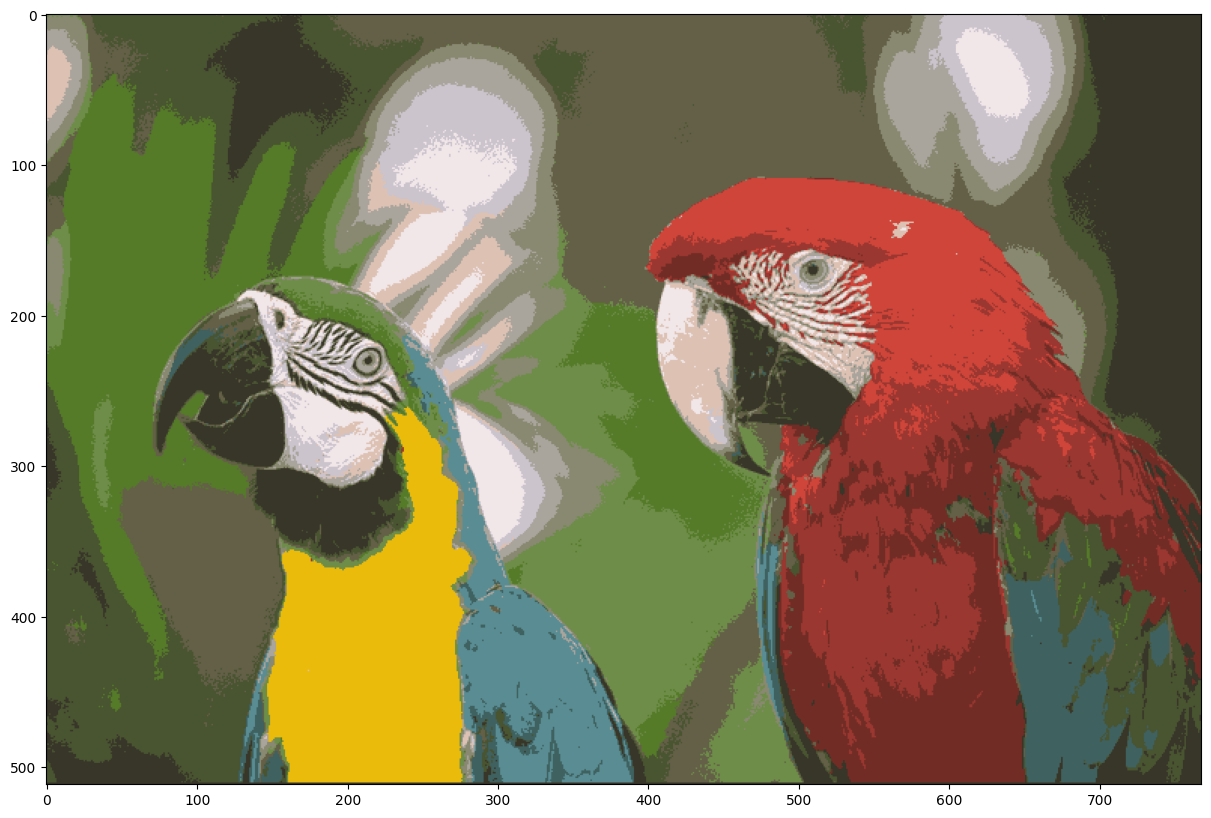

In [26]:
plt.imshow(quantized.astype(np.uint8))

(<Axes: title={'center': 'Dithering (k-means)'}>,
 Text(0.5, 1.0, 'Dithering (k-means)'))

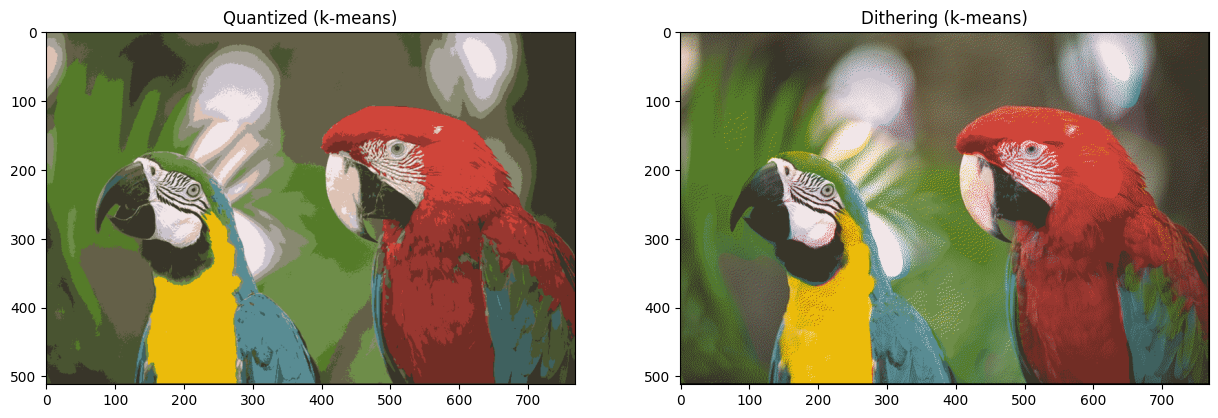

In [27]:
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = img_tmp[r, c, :]
        distances = np.linalg.norm(colors - pixel, axis=1)
        new_pixel = colors[np.argmin(distances)]
        quant_error = pixel - new_pixel
        img_tmp[r, c+1, :]   += quant_error * 7/16
        img_tmp[r+1, c-1, :] += quant_error * 3/16
        img_tmp[r+1, c, :]   += quant_error * 5/16
        img_tmp[r+1, c+1, :] += quant_error * 1/16
        dithering[r, c, :] = new_pixel

dithering = np.clip(dithering, 0, 255)

plt.subplot(121), plt.imshow(quantized.astype(np.uint8)), plt.title('Quantized (k-means)')
plt.subplot(122), plt.imshow(dithering.astype(np.uint8)), plt.title('Dithering (k-means)')

Apply FS dithering the same way you did before.
* How does the result look like to you?

Much better. The colors are more natural and closer to the original, because k-means selects the optimal colors for a specific image and does not use a fixed palette.

* What happens if we use 32 colours?

With 32 colors, the result is even better - more shades allow you to more accurately convey gradients and smooth transitions.
* And what happens if we use 256 colours?

With 256 colors, the image is virtually indistinguishable from the original. The quantization error becomes very small, and the dithering effect is almost imperceptible. In essence, this is approaching a full-color image, so the difference between the quantized and dithered versions disappears.